In [2]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import matplotlib.colors as colors
import metpy.calc as mpcalc
import matplotlib.patches as mpatches
%run ../functions/Yearly_mean.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Transfer_longitude.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [3]:
filepath="/network/rit/lab/zhoulab_rit/lzhuo/data/CESM_input/"
filename="sst_HadOIBl_bc_1.9x2.5_1850_2020_c210521.nc"
ds_sst = xr.open_dataset(filepath+filename)
# SST
SST=ds_sst.SST_cpl.sel(time=slice('1979-01','2020-12'))
# Transfer the longitude
SST=central180_to_0(SST)

## Calculate the SST averaged over the whole boreal warm season

In [4]:
SST_JN=weighted_mean_multiple(SST)
SST_JN

<xarray.DataArray (year: 42, lat: 96, lon: 144)>
array([[[-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        ...,
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995]],

       [[-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
...
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995]],

       [[-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        ...,
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995],
        [-1.79999995, -1.79999995, -1.79999995, ..., -1.79999995,
         -1.79999995, -1.79999995]]])
Coordinates:
  * lon      (lon) float64 -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2016 2017 2018 2019 2020

## Calculate the linear trend

In [5]:
def trend_ps(ds):
    longitude=ds.longitude
    latitude =ds.latitude
    # Create two new dataarrays 
    data=np.zeros(shape=(len(latitude),len(longitude)))
    trend = xr.DataArray(data, coords=[latitude, longitude], dims=["latitude", "longitude"])
    ps    = trend.copy()
    # Calculate the trend and pvalue
    x     = ds.year
    for i in range(0,len(longitude)):
        for j in range(0,len(latitude)):
            y         = ds[:,j,i]
            res       = stats.linregress(x, y)
            trend[j,i]= res.slope
            ps[j,i]   = res.pvalue
    return trend,ps

In [6]:
temp=SST_JN.rename({'lat':'latitude','lon':'longitude'})
trend,ps=trend_ps(temp.sel(year=slice(1979,2020))) # K/year

## Plot the trend

In [24]:
def plot_background(ax,trend,ps):
    lonW = -180
    lonE = 177.5
    latS = -70
    latN = 70.0
    fontsize=10
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
#     ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-120,-60, 0, 60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    lats=trend.latitude
    lons=trend.longitude
    # Specify the intervals
    minVal = -0.5
    maxVal = 0.5+0.05
    cint = 0.05
    intervals = np.arange(minVal, maxVal, cint)
    CF = ax.contourf(lons,lats,trend*10,intervals,transform=proj_data,norm=colors.CenteredNorm(),
                 cmap=plt.get_cmap('seismic'),extend='both')
    # plot the dots using scatter
    nx, ny = np.meshgrid(ps[::3,::3].longitude, ps[::3,::3].latitude)
    area = np.where(ps[::3,::3] < 0.05)
    sig1 = ax.scatter(nx[area], ny[area],  s = 2.5, c = 'k', transform = ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res),color='black',linewidth=0.8)
    ax.add_feature(cfeature.LAND, color='white',zorder=1)
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

def plot_background_area(ax,trend,ps):
    lonW = -180
    lonE = 177.5
    latS = -70
    latN = 70.0
    fontsize=10
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
#     ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-120,-60, 0, 60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([-60,-30,0,30,60], crs=ccrs.PlateCarree())
    lats=trend.latitude
    lons=trend.longitude
    # Specify the intervals
    minVal = -0.5
    maxVal = 0.5+0.05
    cint = 0.05
    intervals = np.arange(minVal, maxVal, cint)
    CF = ax.contourf(lons,lats,trend*10,intervals,transform=proj_data,norm=colors.CenteredNorm(),
                 cmap=plt.get_cmap('seismic'),extend='both')
    ax.add_patch(                                            # Caribbean sea; lat:5-20; lon:-85-(-50)
            mpatches.Rectangle(xy=[-85, 5],
                               width=35,
                               height=15,
                               facecolor='None',
                               edgecolor='blue',
                               lw=1,
                               transform=ccrs.PlateCarree()))
    ax.add_patch(                                            # North Indian Ocean; lat:-5-15; lon:45-90
            mpatches.Rectangle(xy=[45, -5],
                               width=50,
                               height=20,
                               facecolor='None',
                               edgecolor='blue',
                               lw=1,
                               transform=ccrs.PlateCarree()))
    # plot the dots using scatter
    nx, ny = np.meshgrid(ps[::3,::3].longitude, ps[::3,::3].latitude)
    area = np.where(ps[::3,::3] < 0.05)
    sig1 = ax.scatter(nx[area], ny[area],  s = 2.5, c = 'k', transform = ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res),color='black',linewidth=0.8)
    ax.add_feature(cfeature.LAND, color='white',zorder=1)
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

Text(0.5, 1.0, 'SST trend (K/decade)')

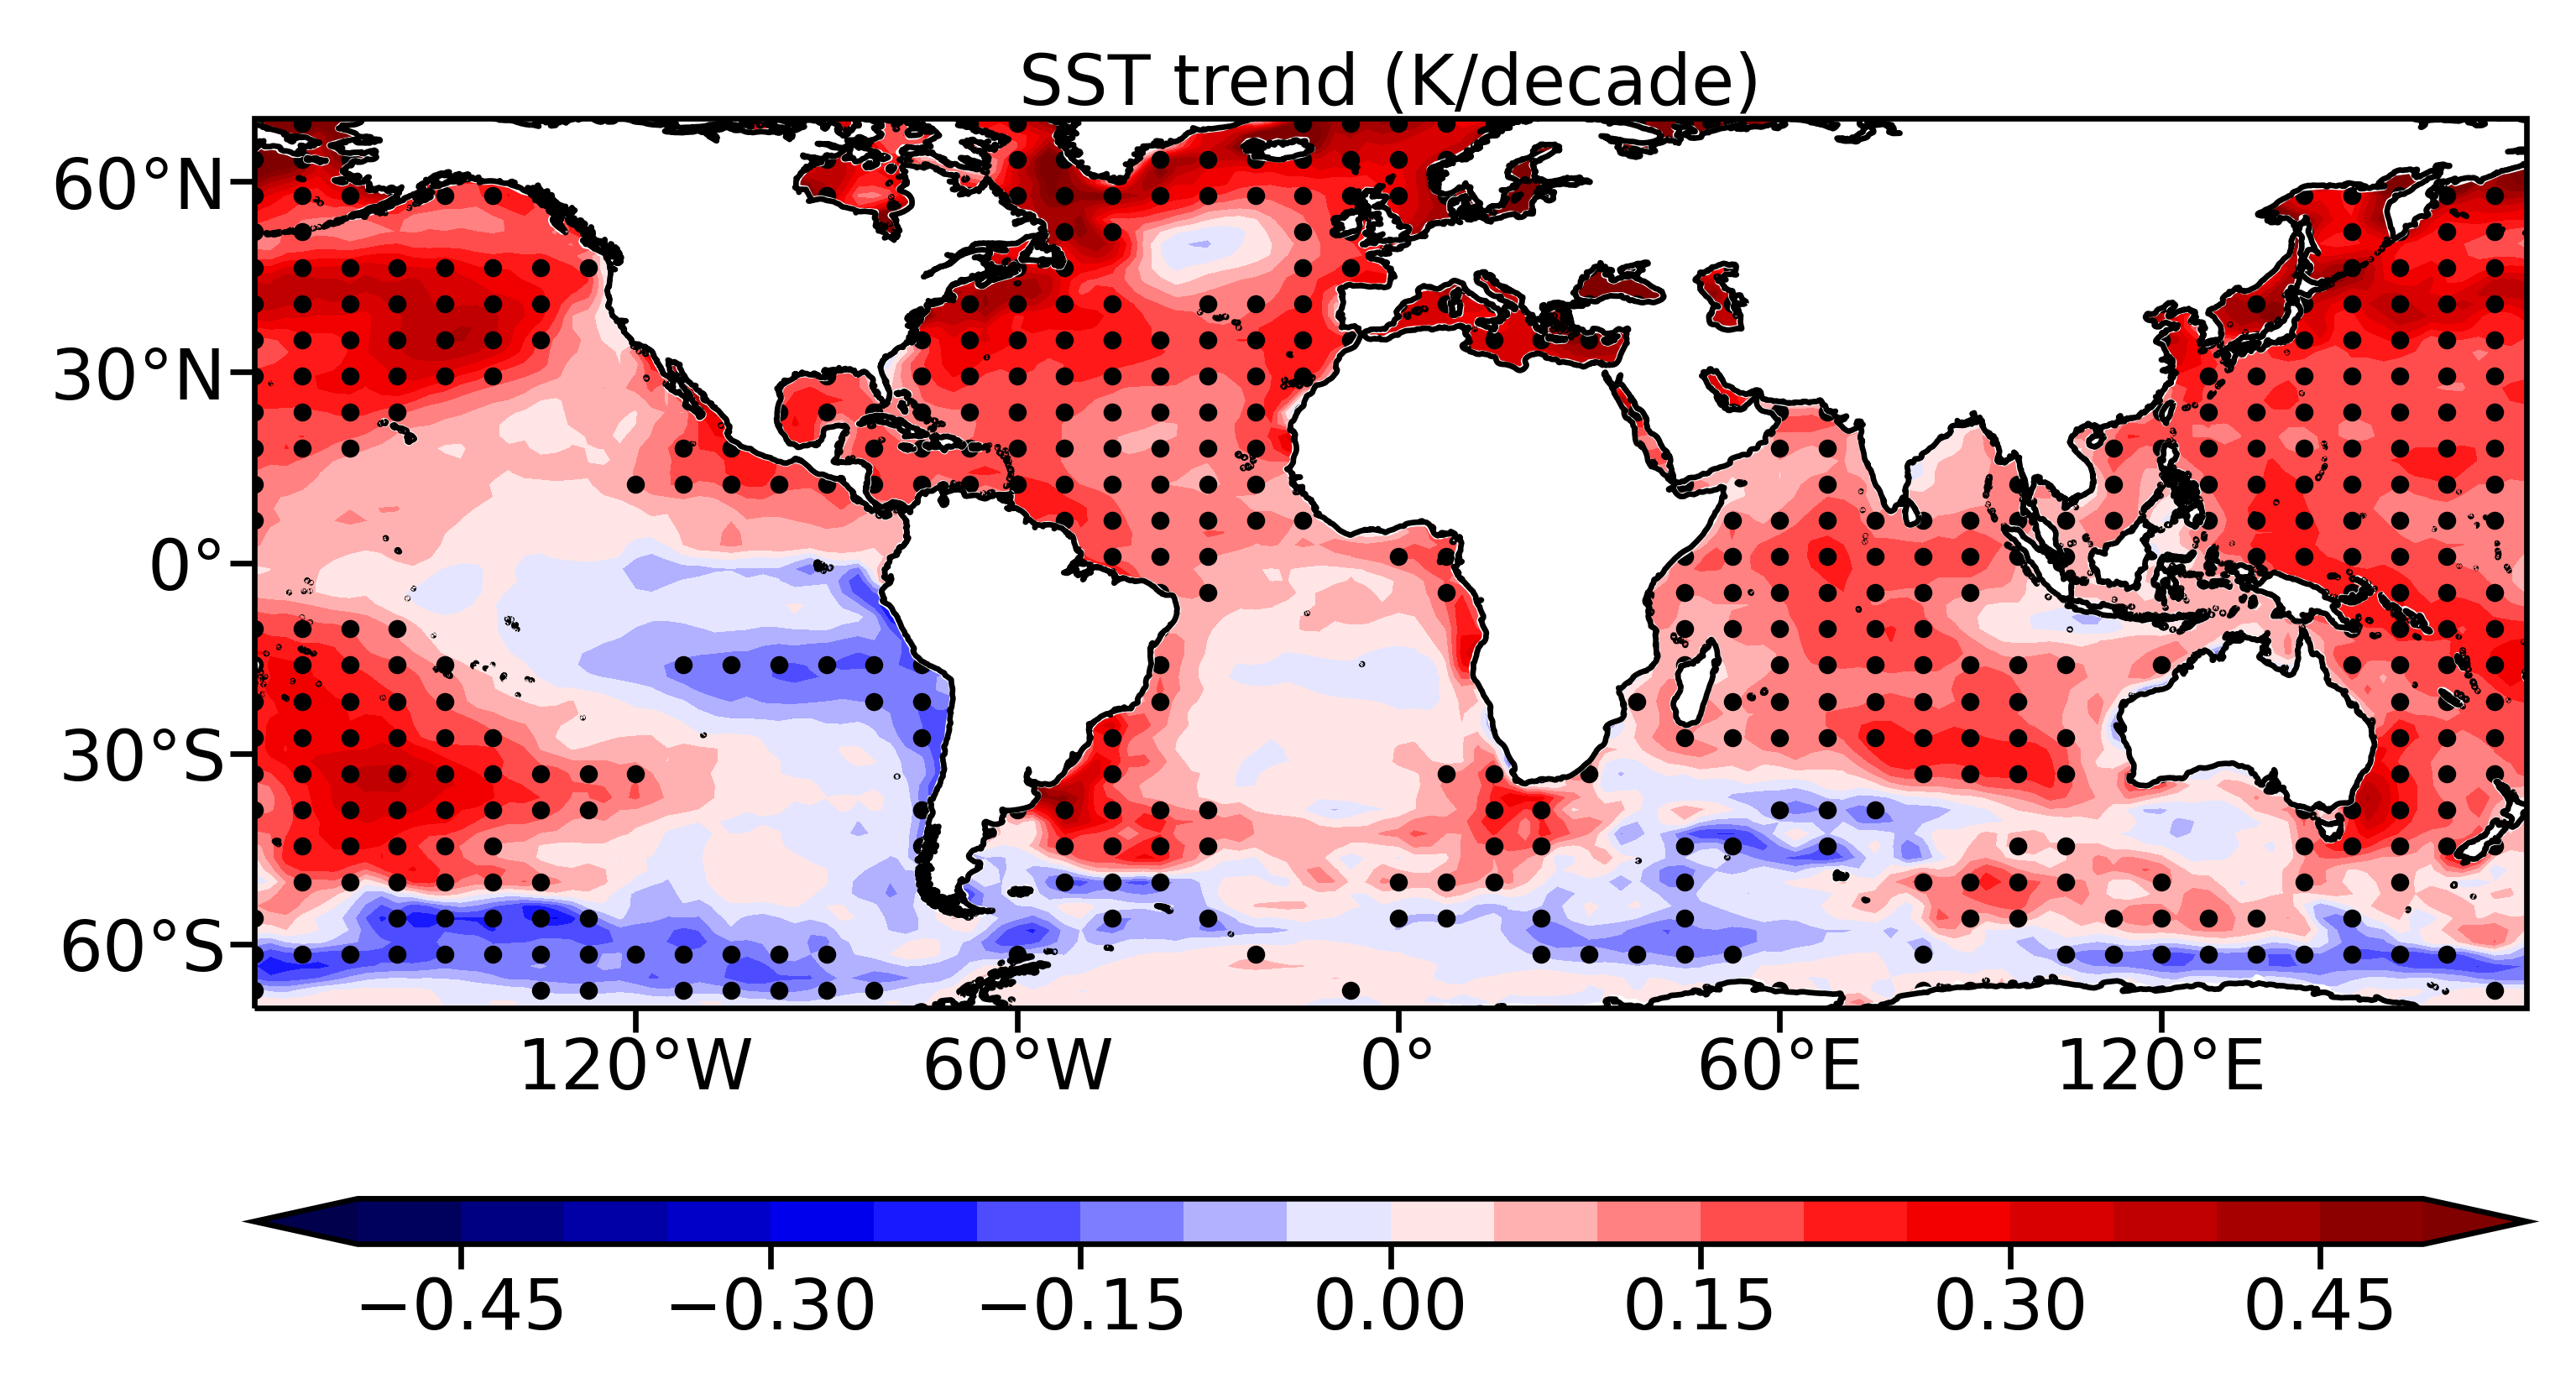

In [10]:
fig = plt.figure(figsize=(5, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

# # Areal extent
# lonW = -20.0
# lonE = 40.0
# latS = 5.0
# latN = 44.0
# latRange = np.arange(latS,latN+1,1.0) # expand the data range a bit beyond the plot range
# lonRange = np.arange(lonW,lonE+1,1.0) # Need to match longitude values to those of the coordinate variable
# fontsize=12
# pad=0.5
#--------------------------------DJF------------------------------------
ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# trend   =trend_ERA5.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
# ps      =ps_ERA5.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
ax1,CF =plot_background(ax,trend,ps)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)

fontsize=10
pad=0.5
ax1.set_title('SST trend (K/decade)',fontsize=fontsize,pad=pad)

Text(0.5, 1.0, 'SST trend (K/decade)')

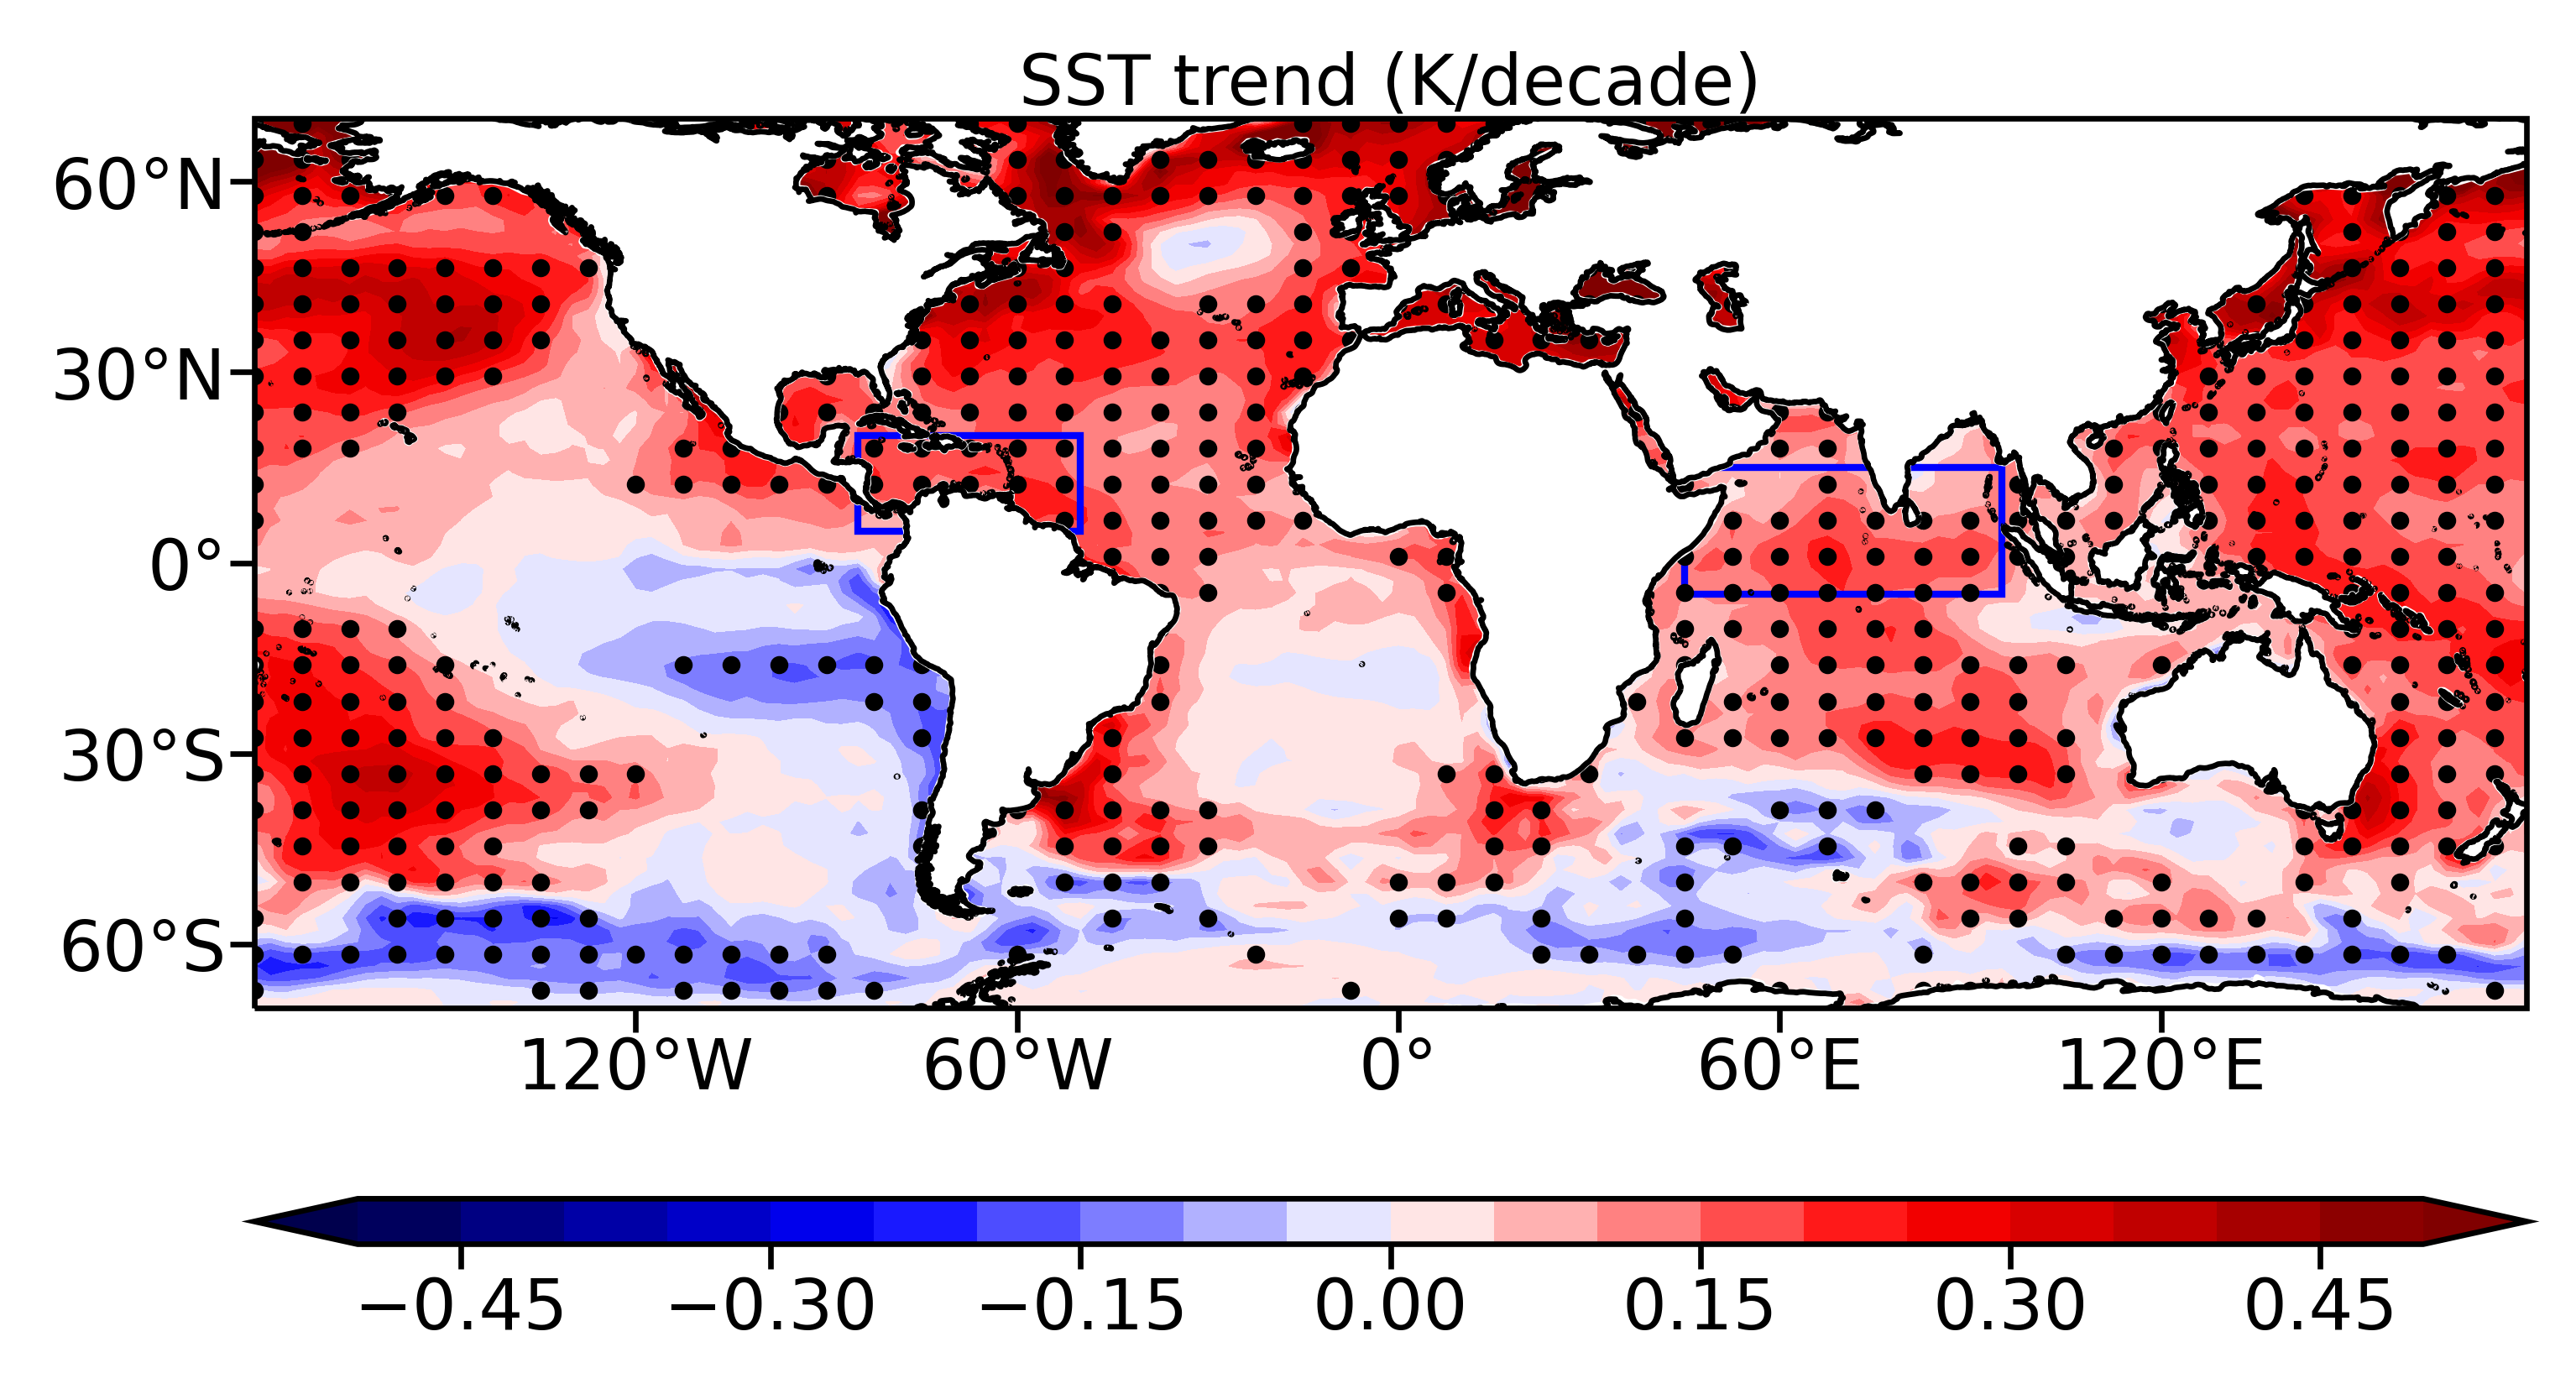

In [25]:
fig = plt.figure(figsize=(5, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

# # Areal extent
# lonW = -20.0
# lonE = 40.0
# latS = 5.0
# latN = 44.0
# latRange = np.arange(latS,latN+1,1.0) # expand the data range a bit beyond the plot range
# lonRange = np.arange(lonW,lonE+1,1.0) # Need to match longitude values to those of the coordinate variable
# fontsize=12
# pad=0.5
#--------------------------------DJF------------------------------------
ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# trend   =trend_ERA5.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
# ps      =ps_ERA5.sel(latitude=slice(latN,latS),longitude=slice(lonW,lonE))
ax1,CF =plot_background_area(ax,trend,ps)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)

fontsize=10
pad=0.5
ax1.set_title('SST trend (K/decade)',fontsize=fontsize,pad=pad)